# **EXP A-01: ConstLW offline**

## **0. Setup**

In [1]:
# Load packages
using Revise
using NeuralLongwave

In [2]:
# Define experiments and general settings
EXP = "exp_A"
SER = "01_CLW_offline"

# Define units
BASELINES = ["0_OBLW", "0_ZeroLW"]
UNITS = ["offline_$(of)" for of in ("direct", "linear", "planck")];

In [3]:
# Reference climate and noise floor (generated once, shared by all experiments)
noise = collect_rollouts("climate_noise", "01_OBLW", ["0_OBLW", "0_OBLW_pert"]; leg = :climate)
ref   = noise.var"0_OBLW"
floor = noise.var"0_OBLW_pert";

In [4]:
# Load all weather and climate rollouts and timings
w = collect_rollouts(EXP, SER, [BASELINES..., UNITS...], leg = :weather)
c = collect_rollouts(EXP, SER, UNITS; leg = :climate)
t = load_timings(EXP, SER);

In [5]:
# Define looks
looks = (;
    var"0_OBLW"    = (; label = "OBLW",   color = :black, marker = :star5),
    var"0_ZeroLW"  = (; label = "ZeroLW", color = :magenta,  marker = :rect),
    offline_direct = (; label = "Direct", color = JL_BLUE),
    offline_linear = (; label = "Linear", color = JL_GREEN),
    offline_planck = (; label = "Planck", color = JL_RED),
);

## **1. Training**

In [7]:
# Collect training runs
runs = collect_runs(EXP, SER, UNITS);

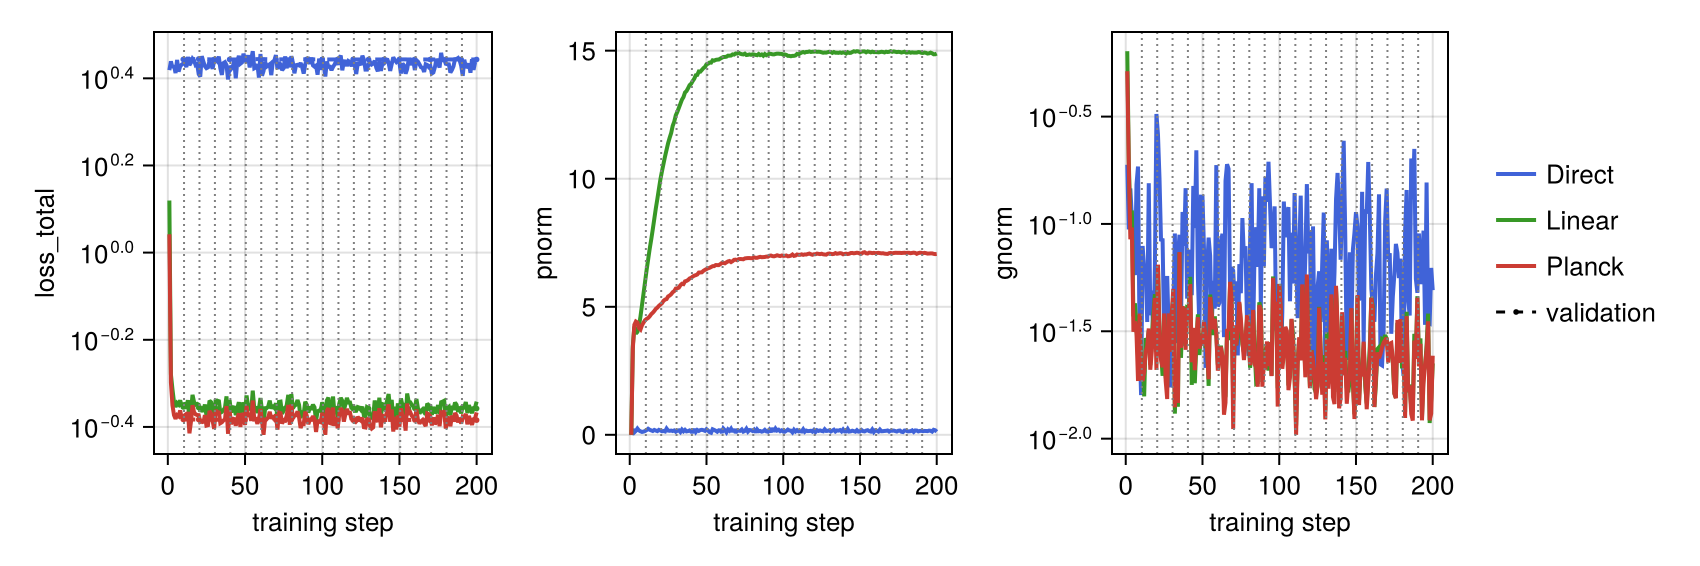

In [8]:
# Plot default plots
plot_training(runs; looks, n_block = 1)

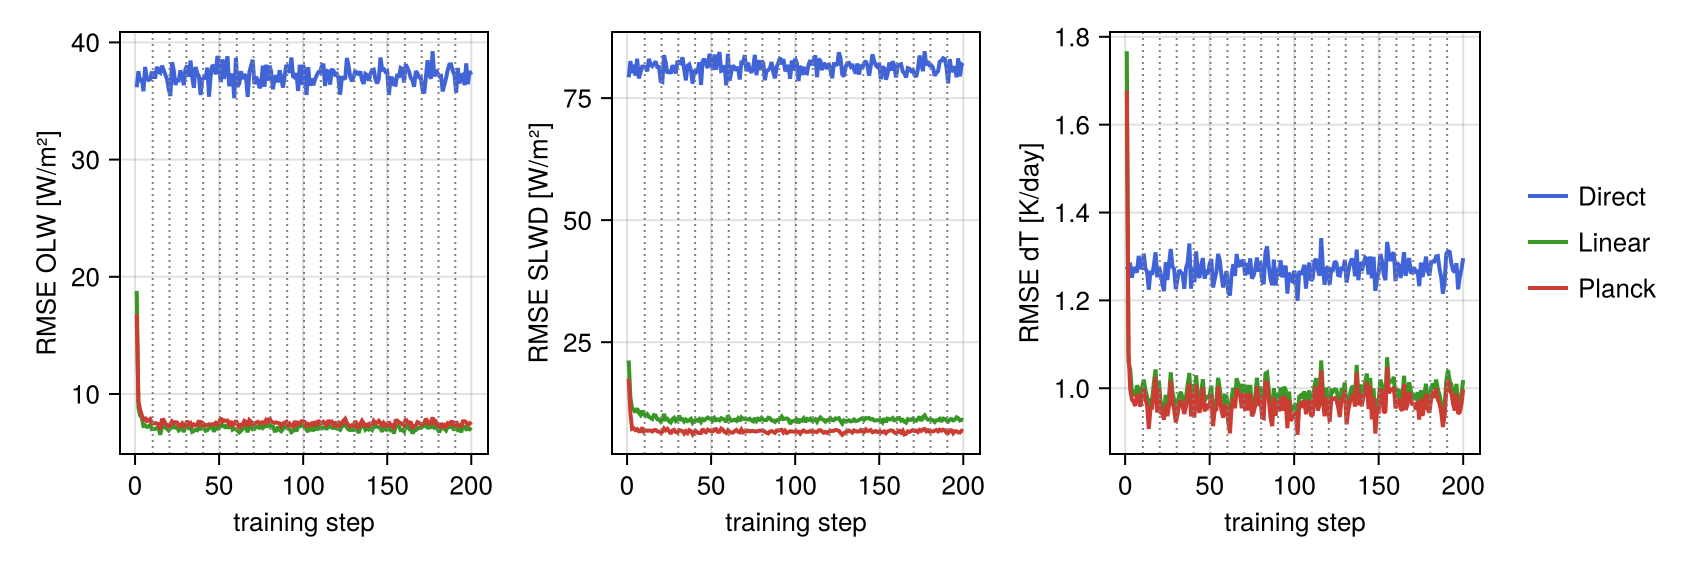

In [9]:
# Plot true variable RMSE
plot_rmse(runs; looks)

## **2. Weather Cost Plane**

In [6]:
# Create tables
wt = weather_table(w)
ct = climate_table(c, ref, floor)
tt = timing_table(t);

In [7]:
# Test reference
test_reference(w.var"0_OBLW")

┌ Info: Reference reproduced exactly for every probe and trajectory.
└ @ NeuralLongwave c:\Code\NeuralLongwave.jl\src\evaluation\rollout_weather.jl:86


Row,probe,max_error,n_exact,n_traj,failed_ics
,Symbol,Float64,Int64,Int64,Array…
1,T,0.0,52,52,Int64[]
2,olw,0.0,52,52,Int64[]
3,slwd,0.0,52,52,Int64[]


In [18]:
using NeuralLongwave

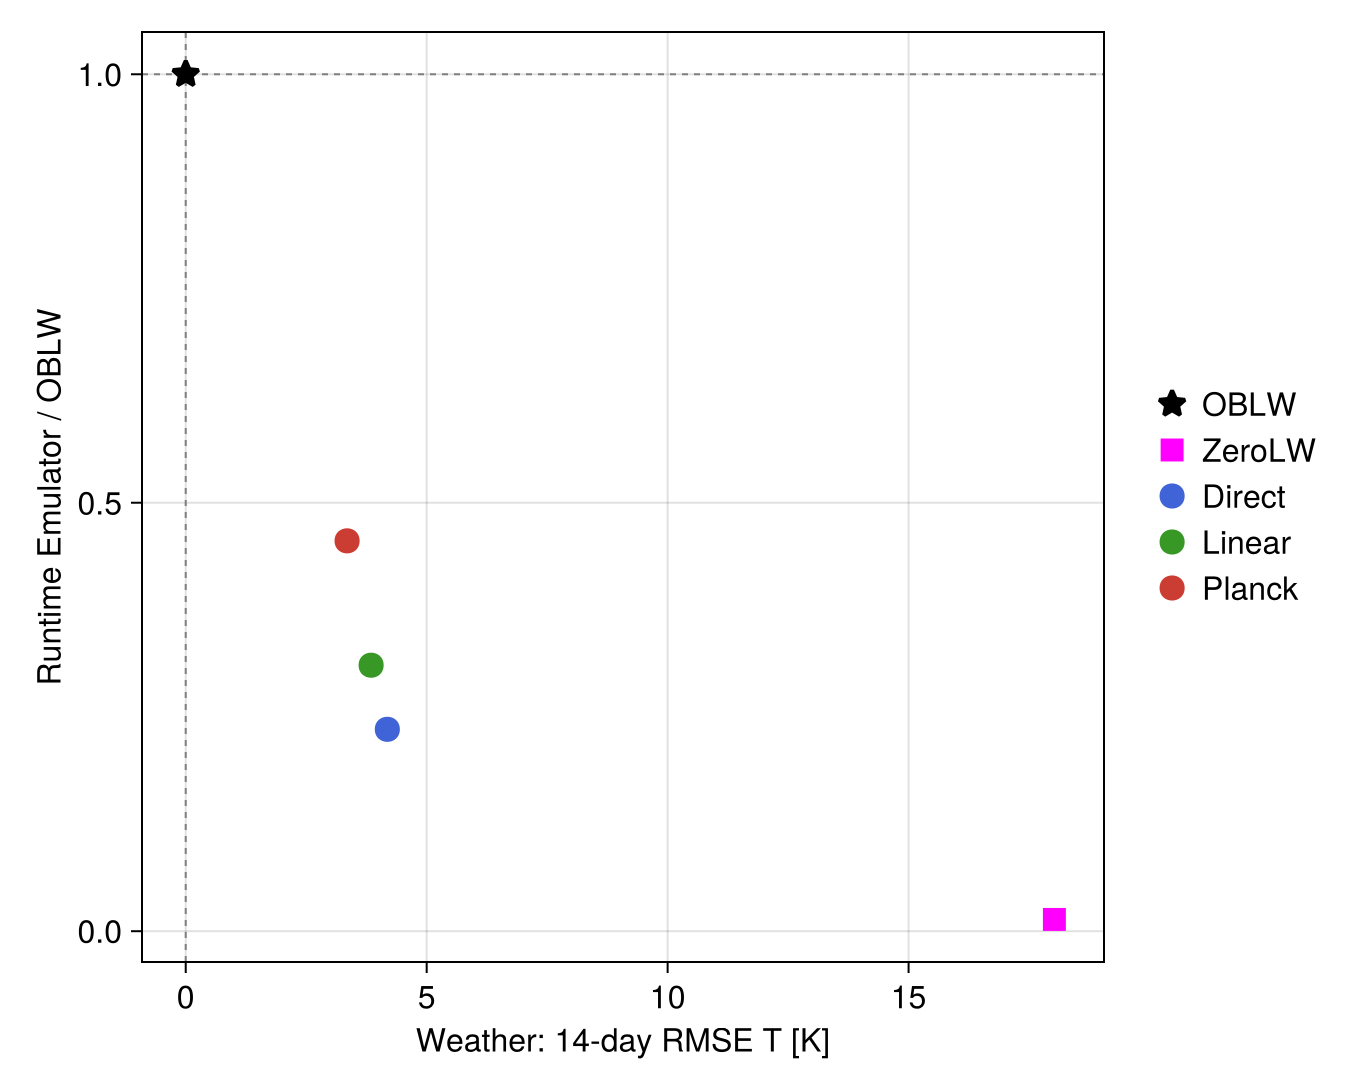

In [19]:
# Plot weather cost plane
plot_weather_cost_plane(wt, tt; looks)

## **3. Weather**

In [64]:
# Define RMSE caps (from set_OBLW/02_spinup.ipynb)
caps = (; 
    T       = (;mean=4.7350603671021805), 
    olw     = (;mean=12.421470279902056), 
    slwd    = (;mean=18.001224927172636), 
    imb_TOA = (;mean=71.88420112276336)
);

### 3.1. ZeroLW Baseline

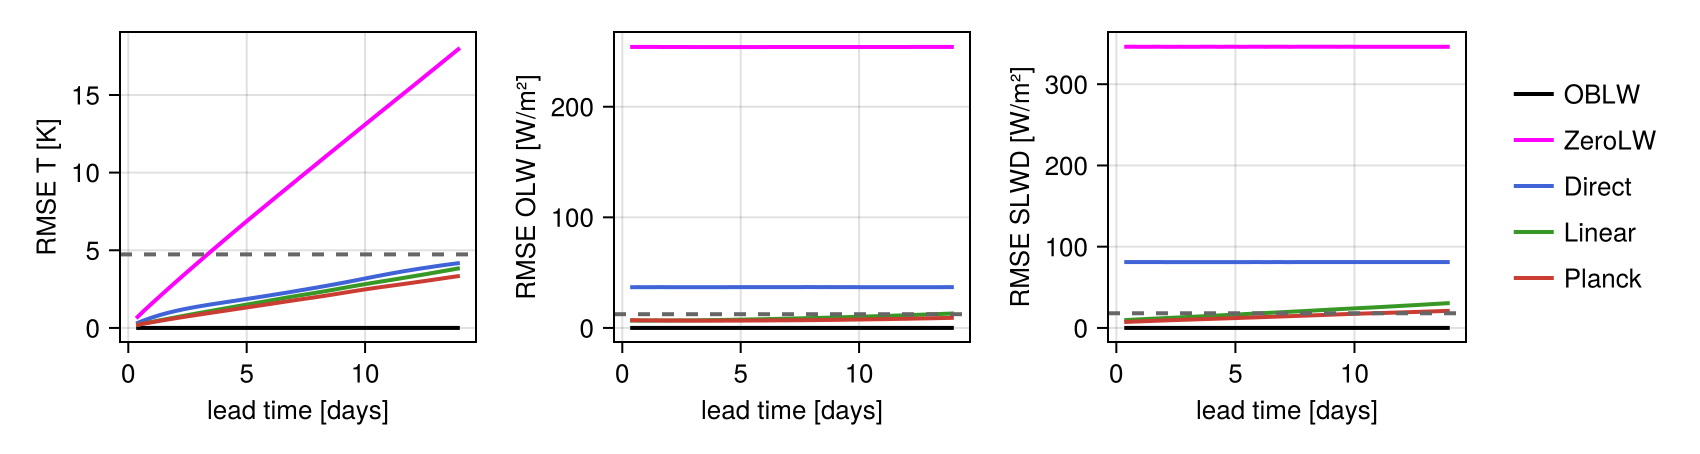

In [ ]:
# Plot weather growth RMSE
plot_weather_growth(w, :rmse; caps, looks)

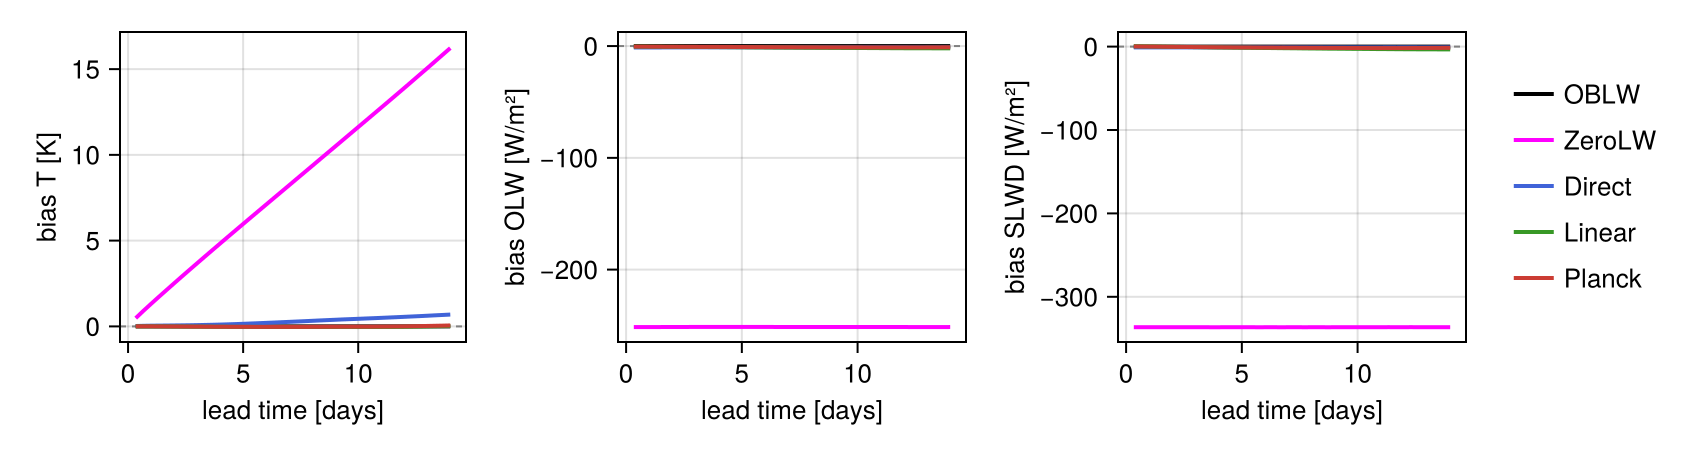

In [ ]:
# Plot weather growth bias
plot_weather_growth(w, :bias; caps, looks)

### 3.2. Output Forms

In [65]:
# Collect relevant emulators
w_em = collect_rollouts(EXP, SER, UNITS, leg=:weather);

#### 3.2.1. Weather Growth

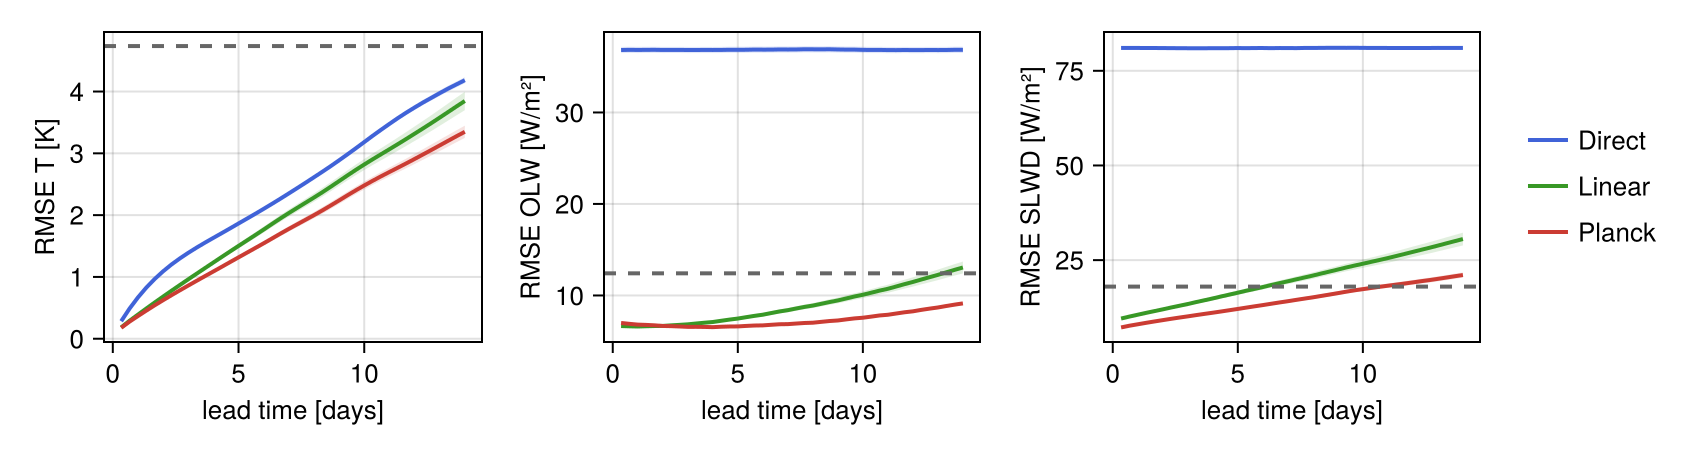

In [66]:
# Plot weather growth RMSE
plot_weather_growth(w_em, :rmse; caps, looks)

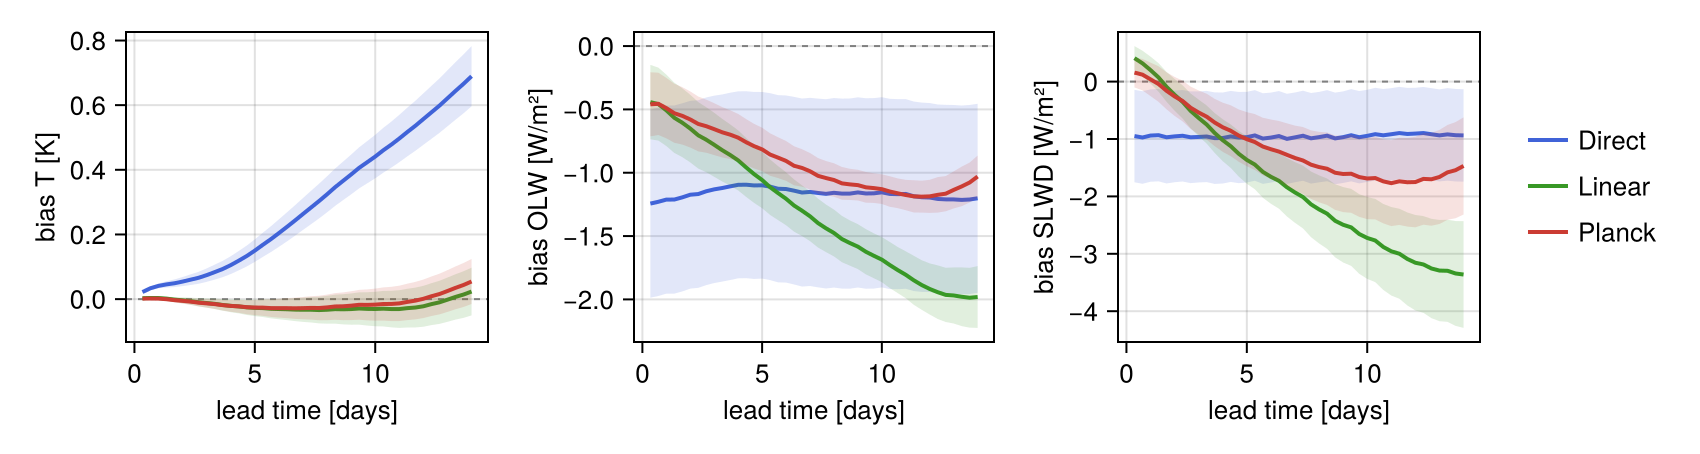

In [69]:
# Plot weather growth bias
plot_weather_growth(w_em, :bias; caps, looks)

#### 3.2.2. Temperature Profile

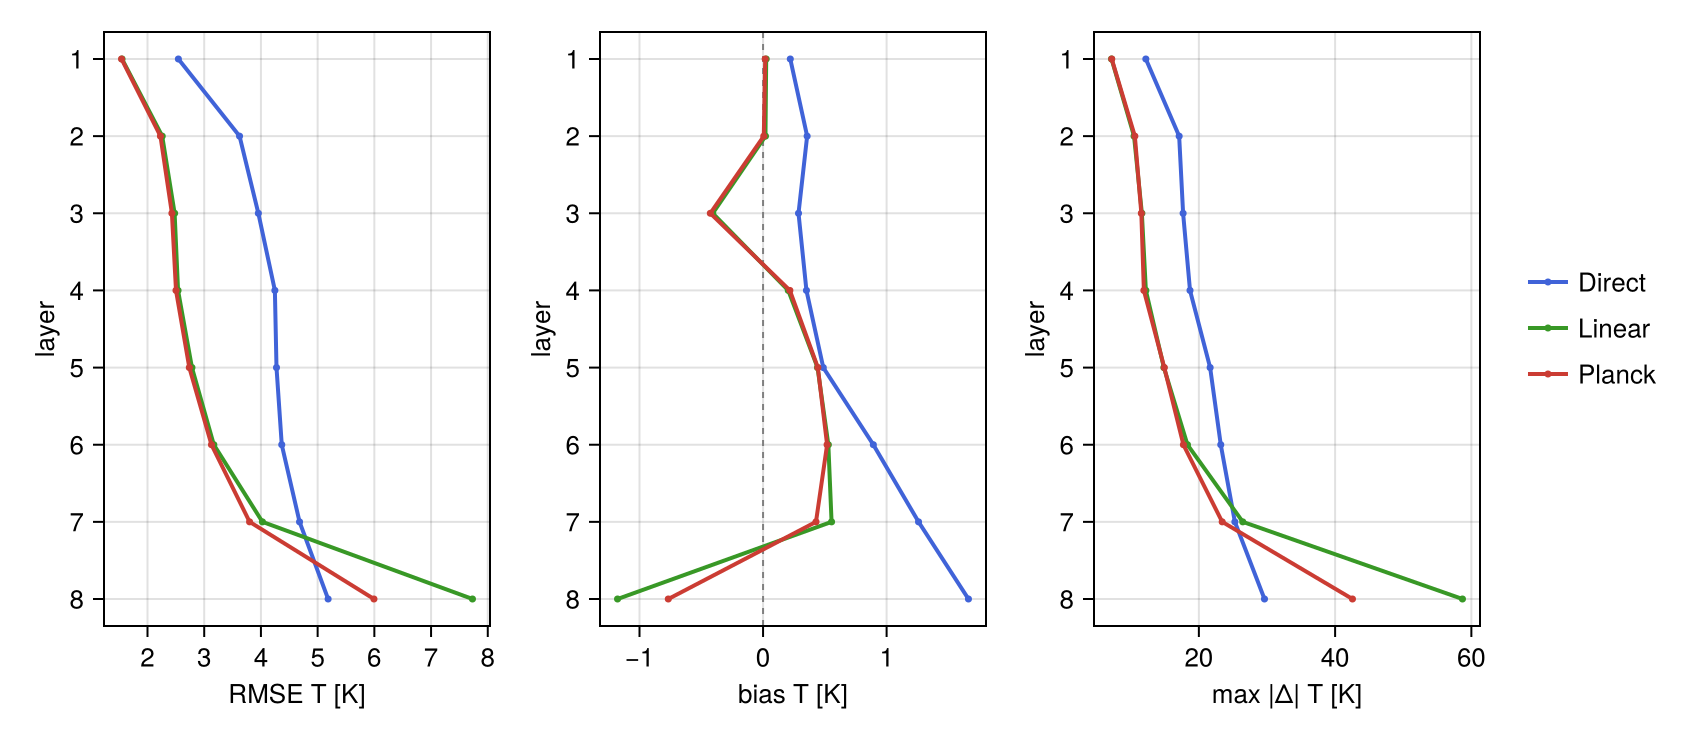

In [70]:
# Temperature profile after 14 days
plot_weather_profile(w_em, :T, 14; looks)

#### 3.2.3. Zonal Sections

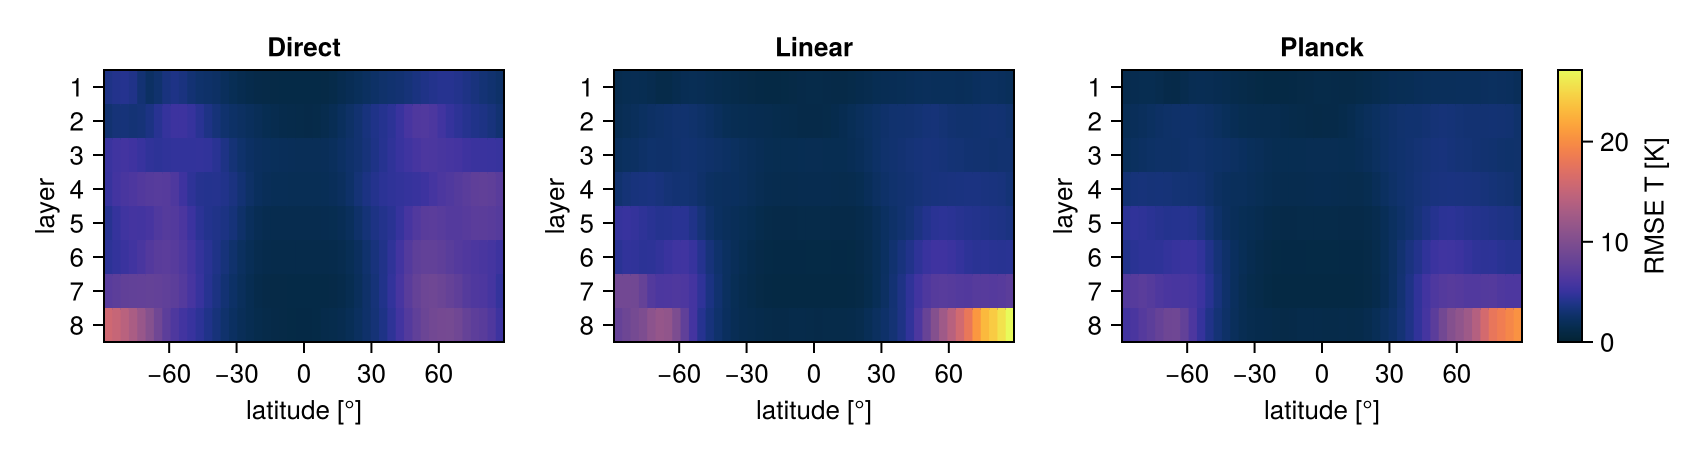

In [73]:
# Zonal temprature rmse section after 14 days
plot_weather_zonal(w_em, :T, 14, :rmse; looks)